In [1]:
!pip install xgboost lightgbm missingno

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import missingno as msno

import warnings
warnings.filterwarnings(action='ignore') 

import os
from os.path import join

In [3]:
data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_titanic')

train = pd.read_csv(os.path.join(data_dir, 'train.csv'))
test = pd.read_csv(os.path.join(data_dir, 'test.csv'))

# 1. 데이터 살펴보기

- PassengerId: 승객 고유 ID로 'gggg_pp' 형식입니다. 앞의 gggg는 그룹 번호, 뒤의 pp는 그룹 내 순번을 의미합니다.  
- HomePlanet: 승객이 거주하던 고향 행성입니다.  
- CryoSleep: 항해 중 동면 상태 여부이며, 동면 시 객실에 격리됩니다.  
- Cabin: 'deck/num/side' 형식의 객실 번호로, side는 P(좌현) 또는 S(우현)를 뜻합니다.  
- Destination: 승객이 내릴 목적지 행성입니다.
- Age: 승객의 나이입니다. 
- VIP: 특별 서비스 유료 이용 여부입니다. 
- RoomService, FoodCourt, ShoppingMall, Spa, VRDeck: 각 편의시설에서 지불한 금액들입니다. 
- Name: 승객의 성과 이름입니다.  
- Transported: 다른 차원으로 이동했는지 여부이며 우리가 예측해야 할 핵심 타겟 변수입니다.

In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [6]:
print(train.shape)  #(891, 12)
print(test.shape)  #(418, 11)

(8693, 14)
(4277, 13)


In [7]:
print(train.columns)
print(test.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')
Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')


In [8]:
y = train['Transported']
del train['Transported']

In [9]:
print(train.columns)
print(train.shape)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')
(8693, 13)


## 변수별 분포 확인

In [10]:
#pd.concat: 전체 데이터 탑색 위해 두 데이터 합침!
train_len = len(train) #추후 다시 데이터 분리 용이하도록 인덱스 저장
data = pd.concat((train, test), axis=0) #axis=0은 기존 데이터 아래 새로운 데이터를 '행'으로 추가

In [11]:
print(data.shape)

(12970, 13)


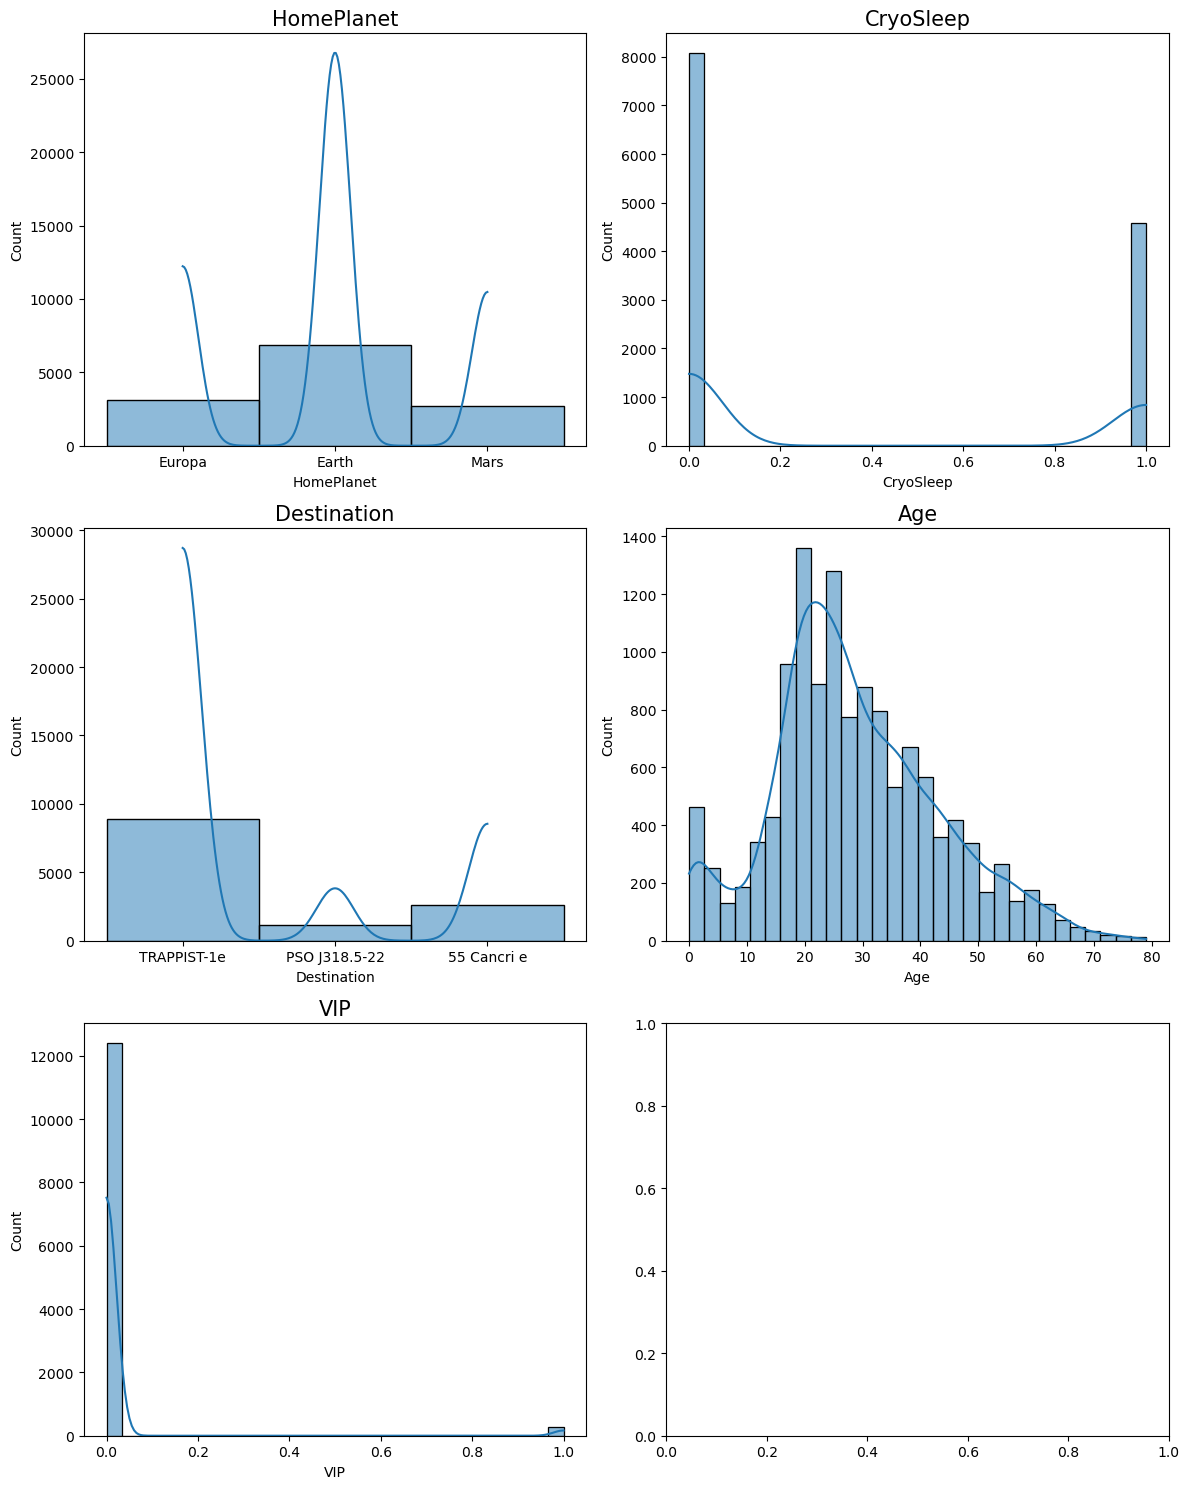

In [12]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15))

# ID같은 변수 외 변수 확인
count = 0
columns = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP']
for row in range(3):
    for col in range(2):
        sns.histplot(data[columns[count]], bins=30, kde=True, ax=ax[row][col])
        ax[row][col].set_title(columns[count], fontsize=15)
        count+=1
        if count == 5 :
            break

plt.tight_layout()
plt.show()

결론:나이는 20-30대가 많고, VIP인 사람은 극히 드물며, 수면에 들어간 사람은 1/3 정도..

# 2. 데이터 전처리

In [13]:
# 중복된 데이터 확인
duplicate_count = data['PassengerId'].duplicated().sum()

print(f"중복된 PassengerId 개수: {duplicate_count}")

중복된 PassengerId 개수: 0


## 2-1. 결측치 확인

In [14]:
print(data.isnull().sum())

# 결측치 비율 계산 (내림차순 정렬)
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("--- 변수별 결측치 비율 (%) ---")
print(missing_percent)

PassengerId       0
HomePlanet      288
CryoSleep       310
Cabin           299
Destination     274
Age             270
VIP             296
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Name            294
dtype: int64
--- 변수별 결측치 비율 (%) ---
CryoSleep       2.390131
ShoppingMall    2.359291
Cabin           2.305320
VIP             2.282190
Name            2.266769
FoodCourt       2.228219
HomePlanet      2.220509
Spa             2.189668
Destination     2.112567
Age             2.081727
VRDeck          2.066307
RoomService     2.027756
PassengerId     0.000000
dtype: float64


결론: 전체 데이터의 2% 정도가 결측치라 결측치 채우는 게 그렇게 중요하진 않음.

<Axes: >

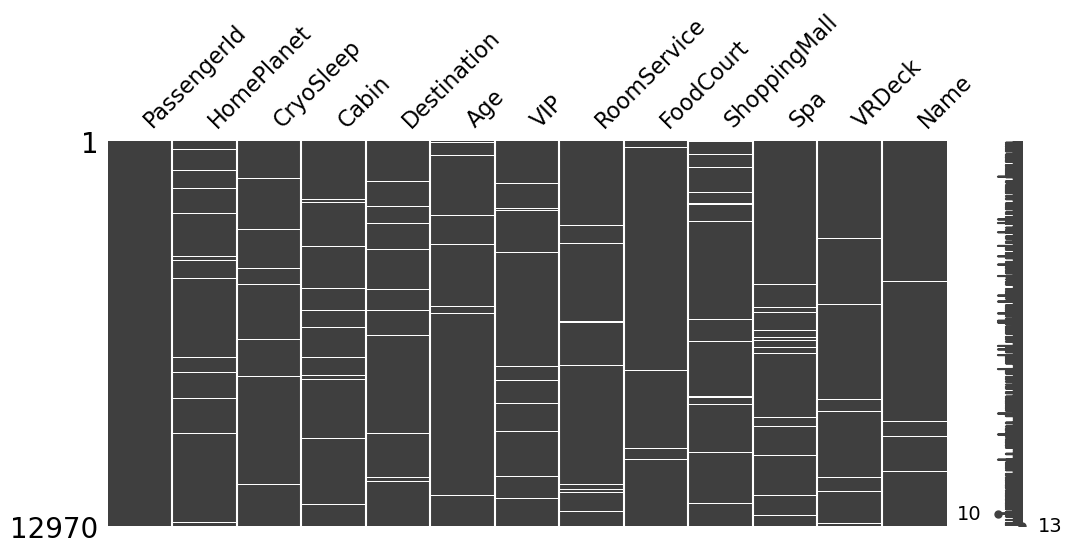

In [15]:
# 결측치 시각화
msno.matrix(data, figsize=(12, 5))

In [16]:
#데이터 형태 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
dtypes: float64(6), object(7)
memory usage: 1.4+ MB


## 2-2. 결측치 처리방법: 
- 연관성 있는 데이터:
- PassengerId(가족일수록) -> HomePlanet(고향 비슷하거나), Cabin(투숙 객실 비슷할까?), 아마 Destination(하선할 행성)도?
- HomePlanet별 Age 분포는 어떠려나? 동면상태에 연관이 있나?
- Age별 destination이나 vip 서비스나 동면상태에 연관이 있나?
- vip별 총 spending(RoomService, FoodCourt, ShoppingMall, Spa.VRDeck) 관계?

연관성 확인 후 별로 연관없으면? 
- 범주형 데이터: 최빈값으로 채우기
- 수치형 데이터: 나이는 중앙값으로, 금액 관련된 것은 0으로 채우기(기록이 없으면 이용하지 않았을 확률이 큼)

### 변수 간 연관성 확인

#### 가설1: passngerID와 HomePlanet, Cabin, Destination 관계 확인

In [17]:
# 전처리: 그룹 번호 추출 및 다인원 그룹 필터링
# 1. 그룹 번호(gggg) 추출
data['Group'] = data['PassengerId'].apply(lambda x: x.split('_')[0])

# 2. 2인 이상인 그룹만 필터링
group_sizes = data['Group'].value_counts()
multi_groups = group_sizes[group_sizes > 1].index
df_multi = data[data['Group'].isin(multi_groups)].copy()

# 3. Cabin에서 Deck(층)과 Side(좌/우현) 추출 (객실 유사도 확인용)
df_multi[['Deck', 'Num', 'Side']] = df_multi['Cabin'].str.split('/', expand=True)

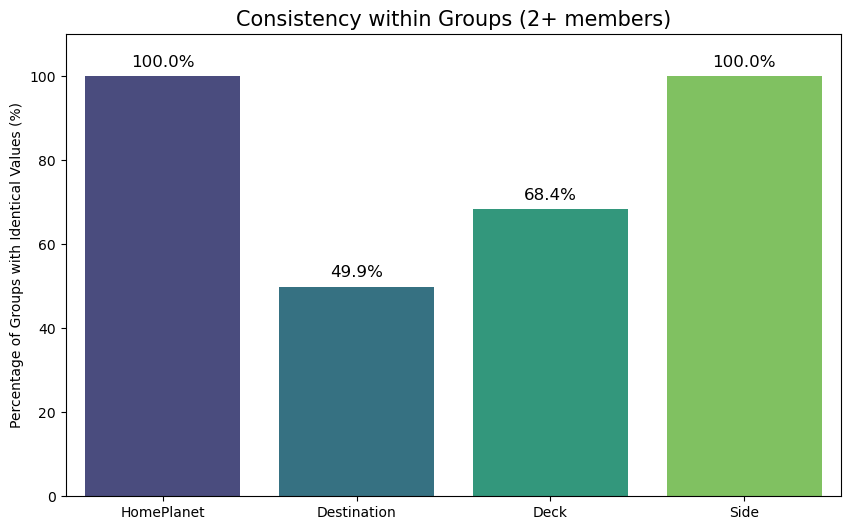

In [18]:
# 시각화: 그룹 내 정보 일치율 확인
# 각 변수별로 그룹 내 '고유값 개수' 확인 (1이면 모두 일치, 2 이상이면 갈라짐)
features = ['HomePlanet', 'Destination', 'Deck', 'Side']
consistency = {}

for col in features:
    # 그룹별 유니크한 값의 개수를 구함
    counts = df_multi.groupby('Group')[col].nunique()
    # 전체 다인원 그룹 중 유니크 값이 1개인(모두 일치하는) 그룹의 비율 계산
    consistency[col] = (counts == 1).mean() * 100

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(consistency.keys()), y=list(consistency.values()), palette='viridis')

# 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                textcoords='offset points')

plt.title('Consistency within Groups (2+ members)', fontsize=15)
plt.ylabel('Percentage of Groups with Identical Values (%)')
plt.ylim(0, 110)
plt.show()

결론: 그룹이 동일한 id의 경우 고향이 동일하며, 같은 쪽 side를 앉으므로, 결측치를 이 패턴에 따라 채운다.
deck의 경우에도 70%면 정보가 없거나 무작위로 채우는 것보다는 나을 것 같다!

In [19]:
# HomePlanet과 Side 결측치 채우기
#1. Group 컬럼
data['Group'] = data['PassengerId'].apply(lambda x: x.split('_')[0])

# 2. Cabin에서 Side 분리 (Side 컬럼 생성)
data[['Deck', 'Num', 'Side']] = data['Cabin'].str.split('/', expand=True)

# 그룹별 정보를 활용해 HomePlanet과 Side 채우기
for col in ['HomePlanet', 'Side']:
    # 같은 그룹 내 다른 승객의 값으로 채움
    data[col] = data[col].fillna(data.groupby('Group')[col].transform('first'))
    
    # 그룹 전체가 결측치라 여전히 남은 경우, 전체 최빈값으로 마무리
    data[col] = data[col].fillna(data[col].mode()[0])

# 확인
print(data[['HomePlanet', 'Side']].isnull().sum())

HomePlanet    0
Side          0
dtype: int64


In [20]:
# deck 결측치 채우기
data['Deck'] = data['Deck'].fillna(data.groupby('Group')['Deck'].transform('first'))

# 남은 결측치는 전체 최빈값으로
data['Deck'] = data['Deck'].fillna(data['Deck'].mode()[0])

# 확인
print(f"남은 data set Deck 결측치 수: {data['Deck'].isnull().sum()}")

남은 data set Deck 결측치 수: 0


In [21]:
# passengerID group과 num 관계 확인
# Num 컬럼을 확실하게 숫자로 변환 (errors='coerce'는 혹시 모를 문자를 NaN으로 처리해줌)
df_multi['Num'] = pd.to_numeric(df_multi['Num'], errors='coerce')

#그룹별 방 번호 차이(Range) 계산
# (최대 방 번호 - 최소 방 번호)
num_range = df_multi.groupby('Group')['Num'].agg(lambda x: x.max() - x.min()).dropna()

# 5. 통계치 확인
same_room_pct = (num_range == 0).mean() * 100
near_room_pct = (num_range <= 2).mean() * 100
print(f"방 번호가 완전히 일치하는 그룹 비율: {same_room_pct:.2f}%")
print(f"방 번호 차이가 2 이하인 그룹 비율: {near_room_pct:.2f}%")

방 번호가 완전히 일치하는 그룹 비율: 68.56%
방 번호 차이가 2 이하인 그룹 비율: 68.60%


결론: 70% 이상의 승객이 가족과 완전히 같은 방을 쓰거나 바로 옆방(차이 2 이하)이므로, 같은 그룹 멤버의 방 번호로 num 채우기

In [22]:
# num 결측치 채우기

# 1. 'Num' 컬럼을 숫자형으로 변환
data['Num'] = pd.to_numeric(data['Num'], errors='coerce')

# 2. 그룹별로 'Num'의 첫 번째 값을 찾아서 결측치에 채우기
# (70% 이상의 확률로 가족과 방 번호가 같거나 매우 유사하므로 가장 안전한 방법입니다)
data['Num'] = data['Num'].fillna(data.groupby('Group')['Num'].transform('first'))

# 3. 그룹 전체가 결측치여서 여전히 비어있는 경우, 전체 데이터의 중앙값으로 채우기
data['Num'] = data['Num'].fillna(data['Num'].median())

# 4. 결과 확인
print(f"남은 data set Num 결측치 수: {data['Num'].isnull().sum()}")

남은 data set Num 결측치 수: 0


#### 가설2: HomePlanet과 Age, CryoSleep의 관계 확인

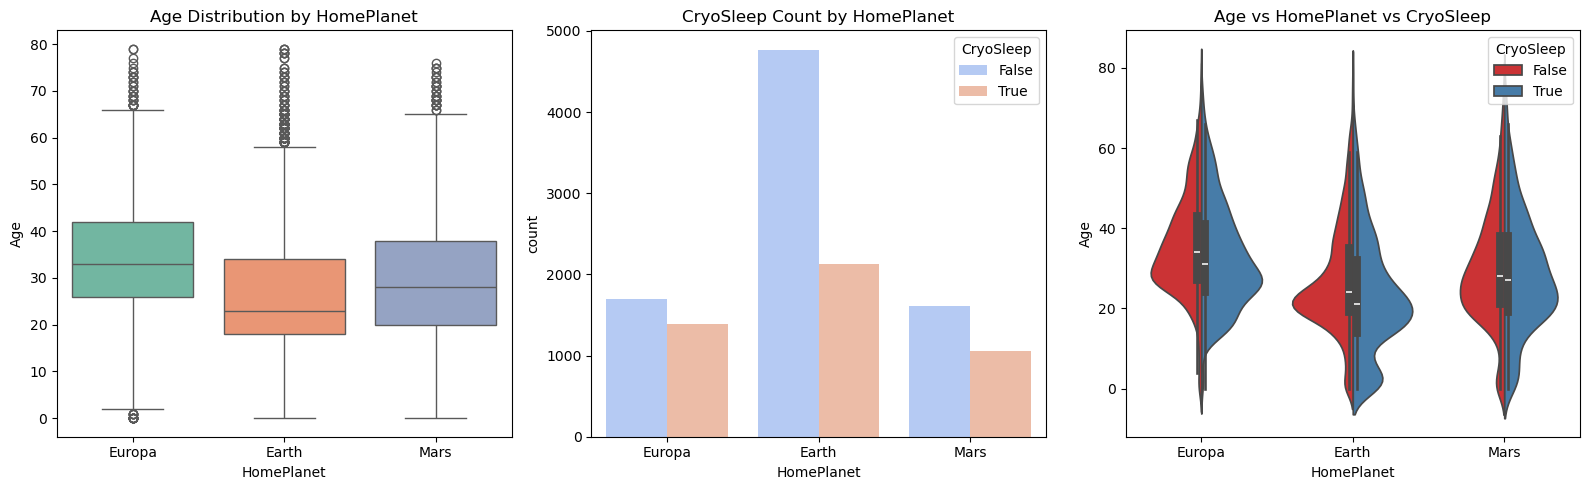

In [23]:
# 0. 인덱스 중복 문제 해결 (기존 인덱스를 버리고 새로 0, 1, 2... 부여)
data = data.reset_index(drop=True)

# 그 다음 기존 그래프 코드 실행
plt.figure(figsize=(16, 5))

# 1. 행성별 나이 분포 (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(data=data, x='HomePlanet', y='Age', palette='Set2')
plt.title('Age Distribution by HomePlanet')

# 2. 행성별 동면 여부 비중 (Countplot)
plt.subplot(1, 3, 2)
sns.countplot(data=data, x='HomePlanet', hue='CryoSleep', palette='coolwarm')
plt.title('CryoSleep Count by HomePlanet')

# 3. 행성별 + 동면여부별 나이 분포 (Violinplot)
plt.subplot(1, 3, 3)
sns.violinplot(data=data, x='HomePlanet', y='Age', hue='CryoSleep', split=True, palette='Set1')
plt.title('Age vs HomePlanet vs CryoSleep')

plt.tight_layout()
plt.show()

결론:  
1. hompelanet별로 Age 결측치 median 채우면 좋다.
2. CryoSleep는 행성과 큰 연관성이 없다..

In [24]:
# 1. 행성(HomePlanet)에 따른 나이(Age)의 중앙값으로 채우기
data['Age'] = data['Age'].fillna(data.groupby(['HomePlanet'])['Age'].transform('median'))

# 2. 혹시나 여전히 남은 결측치가 있다면(두 정보가 다 없는 경우), 전체 중앙값으로 마무리
data['Age'] = data['Age'].fillna(data['Age'].median())

print(f"남은 data set Age 결측치 수: {data['Age'].isnull().sum()}")

남은 data set Age 결측치 수: 0


#### 가설 3: Age와 Destination, VIP, CryoSleep 관계 확인

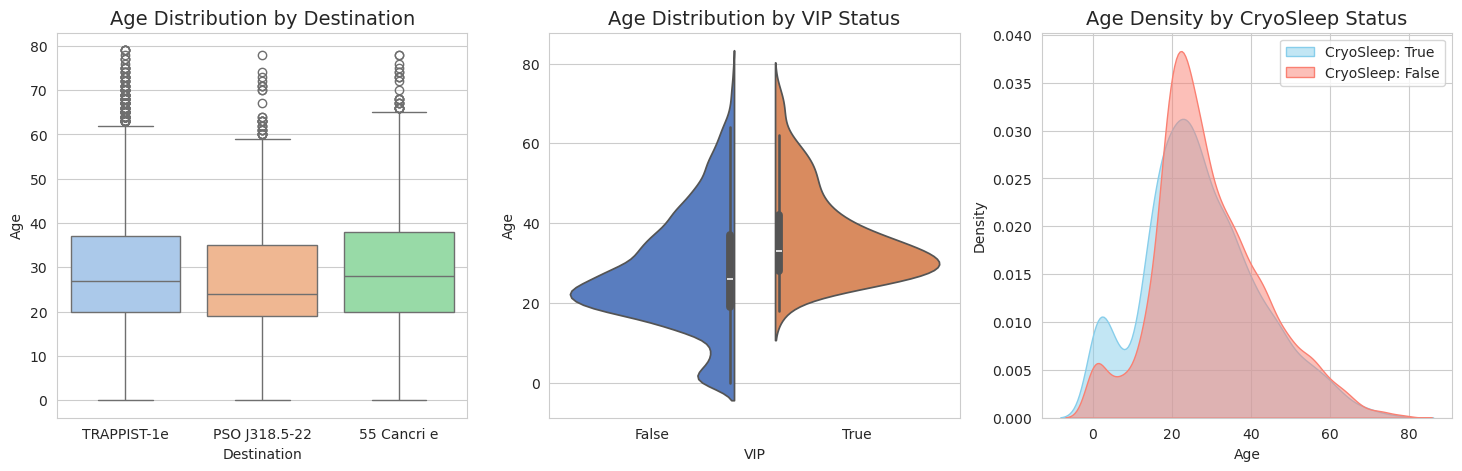

In [25]:
# 그래프 크기 및 스타일 설정
plt.figure(figsize=(18, 5))
sns.set_style("whitegrid") # 배경을 하얗게 설정하여 가독성 높임

# 1. 목적지(Destination)별 나이 분포 (Boxplot)
# 목적지에 따라 선호하는 연령대가 다른지 확인합니다.
plt.subplot(1, 3, 1)
sns.boxplot(data=data, x='Destination', y='Age', palette='pastel')
plt.title('Age Distribution by Destination', fontsize=14)

# 2. VIP 여부별 나이 분포 (Violinplot)
# VIP 서비스를 이용하는 사람들이 주로 어떤 연령대인지 확인합니다.
# 바이올린 모양을 통해 특정 나이대에 뭉쳐있는지 볼 수 있습니다.
plt.subplot(1, 3, 2)
sns.violinplot(data=data, x='VIP', y='Age', palette='muted', split=True)
plt.title('Age Distribution by VIP Status', fontsize=14)

# 3. 동면(CryoSleep) 여부별 나이 분포 (KDE Plot)
plt.subplot(1, 3, 3)
# CryoSleep이 True인 경우
sns.kdeplot(data=data[data['CryoSleep'] == True]['Age'], fill=True, color="skyblue", label="CryoSleep: True", alpha=0.5)
# CryoSleep이 False인 경우 추가
sns.kdeplot(data=data[data['CryoSleep'] == False]['Age'], fill=True, color="salmon", label="CryoSleep: False", alpha=0.5)

plt.title('Age Density by CryoSleep Status', fontsize=14)
plt.legend() # 범례 표시

In [26]:
# VIP 여부별 실제 인원수 확인
print(data['VIP'].value_counts())

# 비율로 확인
print("\nVIP 비율:")
print(data['VIP'].value_counts(normalize=True) * 100)

#VIP 연령 통계 확인
vip_age_stats = data[data['VIP'] == True]['Age'].describe()

print("\n--- VIP 승객 나이 통계 ---")
print(vip_age_stats)

VIP
False    12401
True       273
Name: count, dtype: int64

VIP 비율:
VIP
False    97.845984
True      2.154016
Name: proportion, dtype: float64

--- VIP 승객 나이 통계 ---
count    273.000000
mean      36.619048
std       11.176785
min       18.000000
25%       28.000000
50%       33.000000
75%       42.000000
max       73.000000
Name: Age, dtype: float64


결론: Age 별 destination, cryptosleep 차이없음.
단, vip 와 Age의 관계는 있음.
- 나이가 18세 미만인 승객의 VIP 결측치는 모두 **False**로 채운다.

다른 아래 가설4에서 더 관계 없으면 
- VIP가 결측치인 경우는 전체 최빈값(False)으로 채운다.

In [27]:
#18세 미만의 사람은 VIP false로 결측치 채우기
data.loc[(data['VIP'].isnull()) & (data['Age'] < 18), 'VIP'] = False

print(f"남은 data set VIP 결측치 수: {data['VIP'].isnull().sum()}")

남은 data set VIP 결측치 수: 242


#### 가설 4: VIP와 총 spending(RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)의 관계

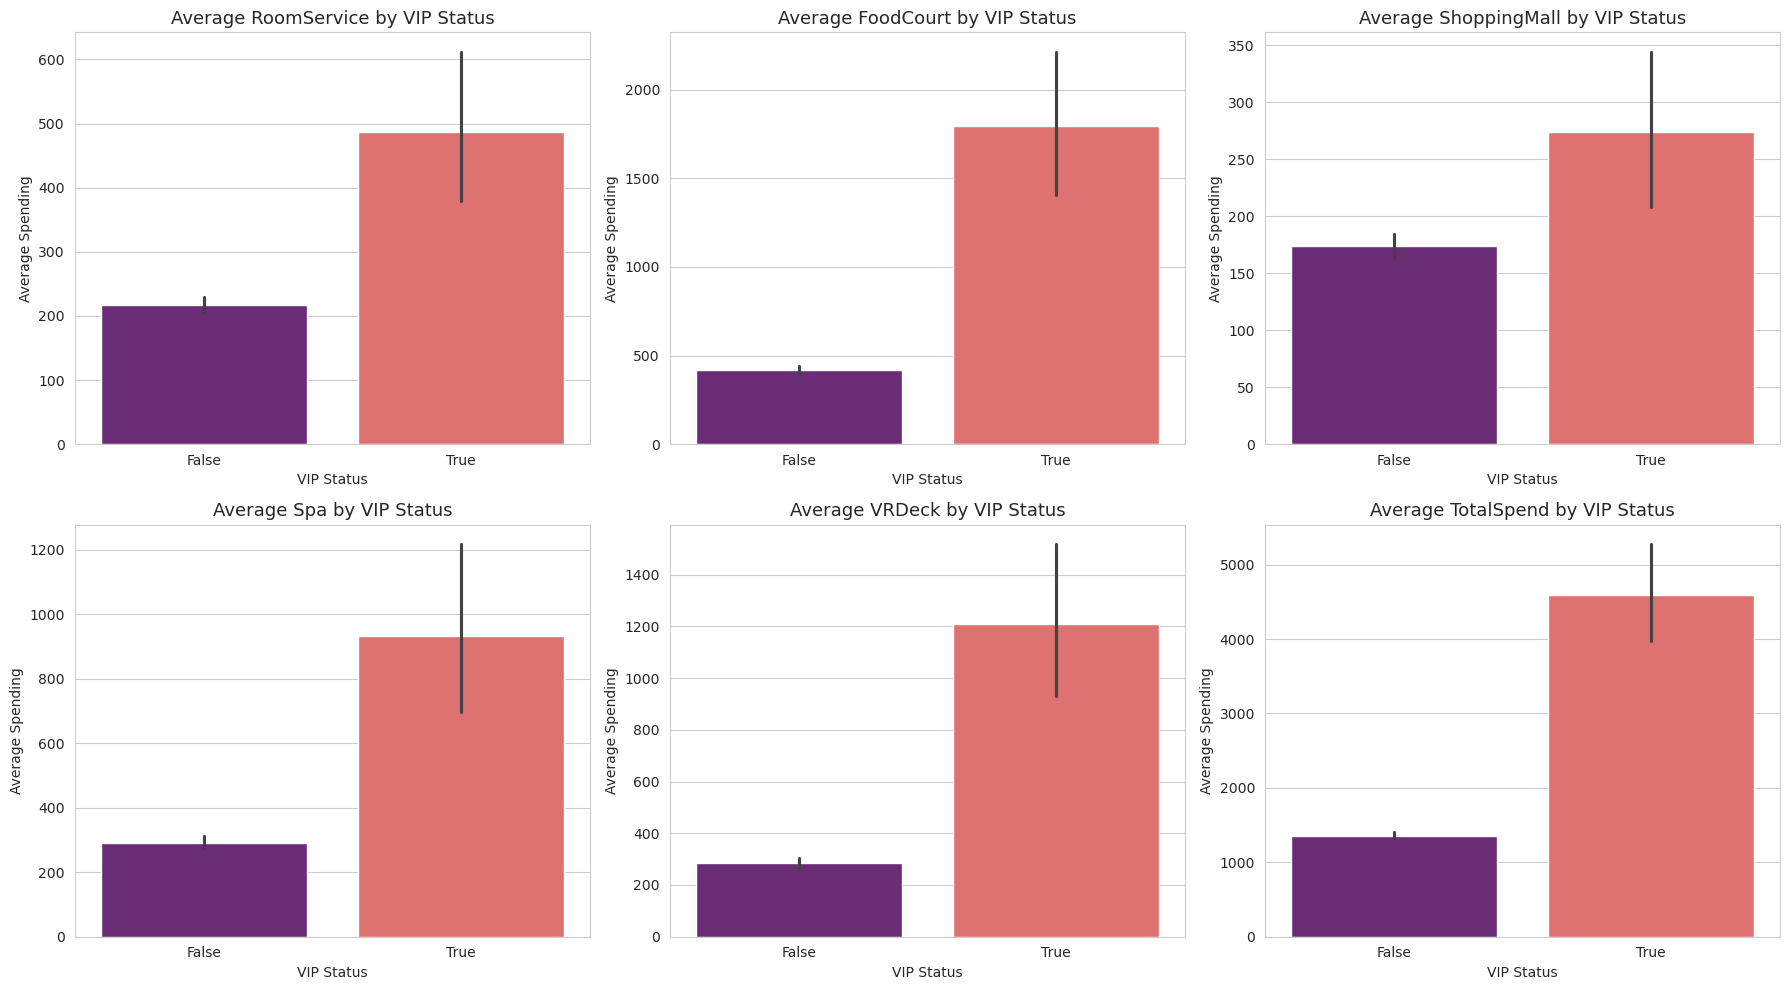

In [28]:
# 1. 지출 관련 컬럼 리스트 및 전체 지출 합계 생성
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data['TotalSpend'] = data[exp_cols].sum(axis=1)

# 2. 시각화 설정 (2행 3열 그리드)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 3. 각 지출 항목별로 VIP 여부에 따른 평균 지출액 그래프 그리기
for i, col in enumerate(exp_cols + ['TotalSpend']):
    sns.barplot(data=data, x='VIP', y=col, ax=axes[i], palette='magma')
    axes[i].set_title(f'Average {col} by VIP Status', fontsize=13)
    axes[i].set_xlabel('VIP Status')
    axes[i].set_ylabel('Average Spending')

plt.tight_layout()
plt.show()

결론: VIP의 평균 총 지출액(TotalSpend)이 대략 4,000~5,000 이상으로 보입니다. 반면 일반 승객은 1,000 미만
VIP false그룹의 total spending 최대값을 기준 초과는 VIP로 결측치 채우기

In [29]:
# 1. VIP가 False인 승객들의 지출 통계 확인
non_vip_stats = data[data['VIP'] == False]['TotalSpend'].describe()
max_non_vip_spend = data[data['VIP'] == False]['TotalSpend'].max()
upper_99_non_vip = data[data['VIP'] == False]['TotalSpend'].quantile(0.99)

print(f"일반 승객(VIP=False)의 지출 최댓값: {max_non_vip_spend}")
print(f"일반 승객 중 상위 1% 시작 지점: {upper_99_non_vip}")

일반 승객(VIP=False)의 지출 최댓값: 35987.0
일반 승객 중 상위 1% 시작 지점: 13008.219999999994


In [30]:
# 2. 기준선 결정(일반승객의 지출 최대값은 이상치에 가까우므로 상위 1% 기준 사용)
threshold = 15000

# 지출이 일반인 최댓값을 넘어가면 무조건 True
data.loc[(data['VIP'].isnull()) & (data['TotalSpend'] > threshold), 'VIP'] = True

print(f"남은 data set VIP 결측치 수: {data['VIP'].isnull().sum()}")

남은 data set VIP 결측치 수: 237


In [31]:
# 나머지는 최빈값(False)으로 마무리
data['VIP'] = data['VIP'].fillna(False)
print(f"남은 data set VIP 결측치 수: {data['VIP'].isnull().sum()}")

남은 data set VIP 결측치 수: 0


#### 기타 나머지 변수 결측치 채우기

In [32]:
# 범주형 컬럼 리스트: 최빈값으로 채우기
cols_cat = ['CryoSleep', 'Destination']

for col in cols_cat:
    # 최빈값 [0]번째 값을 가져와 채움
    data[col] = data[col].fillna(data[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

print(f"남은 data set CryoSleep 결측치 수: {data['CryoSleep'].isnull().sum()}")
print(f"남은 data set Destination 결측치 수: {data['Destination'].isnull().sum()}")

남은 data set CryoSleep 결측치 수: 0
남은 data set Destination 결측치 수: 0


In [33]:
data.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           299
Destination       0
Age               0
VIP               0
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Name            294
Group             0
Deck              0
Num               0
Side              0
TotalSpend        0
dtype: int64

## 2-3. 변수와 타겟 데이터 간의 관계 파악

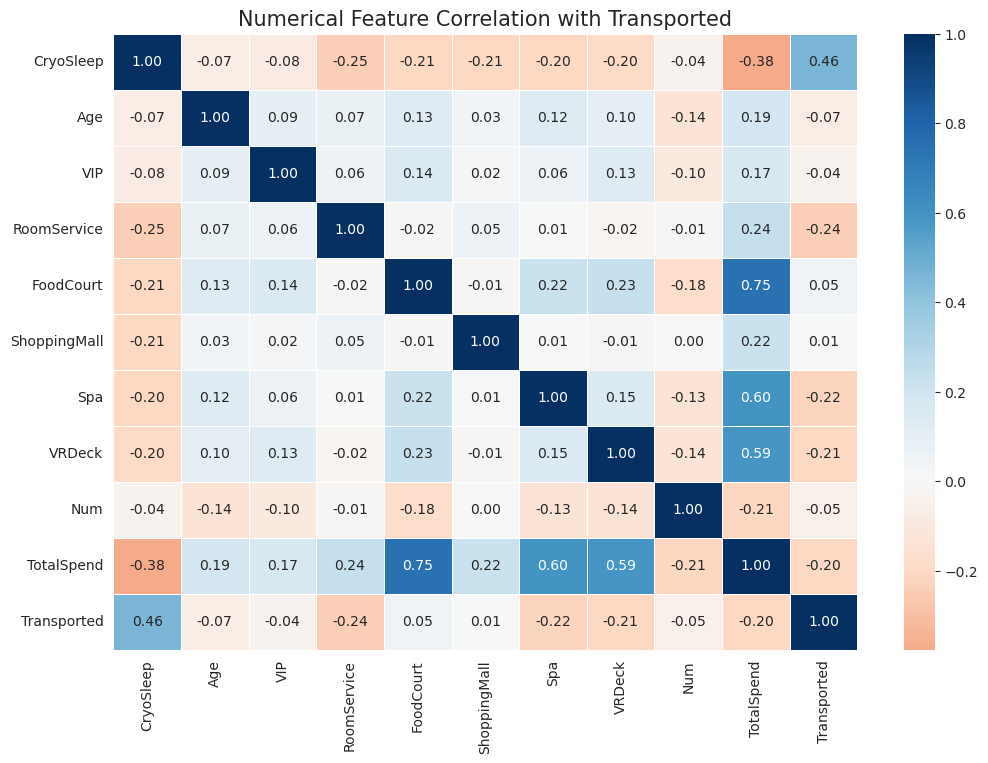

In [34]:
# 1. 분석용 데이터 생성 (훈련 데이터 + 타겟값)
train_analysis = data.iloc[:train_len].copy()
train_analysis['Transported'] = y

# 2. 수치형 변수(숫자, 불리언)만 선택
# bool 타입은 자동으로 0과 1로 계산되어 히트맵에 포함됩니다.
numeric_data = train_analysis.select_dtypes(include=['number', 'bool'])

# 3. 상관계수 계산
corr_matrix = numeric_data.corr()

# 4. 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True,      # 숫자 표시
            fmt='.2f',       # 소수점 둘째자리까지
            cmap='RdBu',     # 양의 상관관계는 파란색, 음의 상관관계는 빨간색
            center=0,        # 0을 기준으로 색상 중앙 설정
            linewidths=0.5)  # 칸 사이 간격

plt.title('Numerical Feature Correlation with Transported', fontsize=15)
plt.show()

결론:  
1. 타겟변수와 가장 연관이 있는 변수는 cryosleep임! 0.46

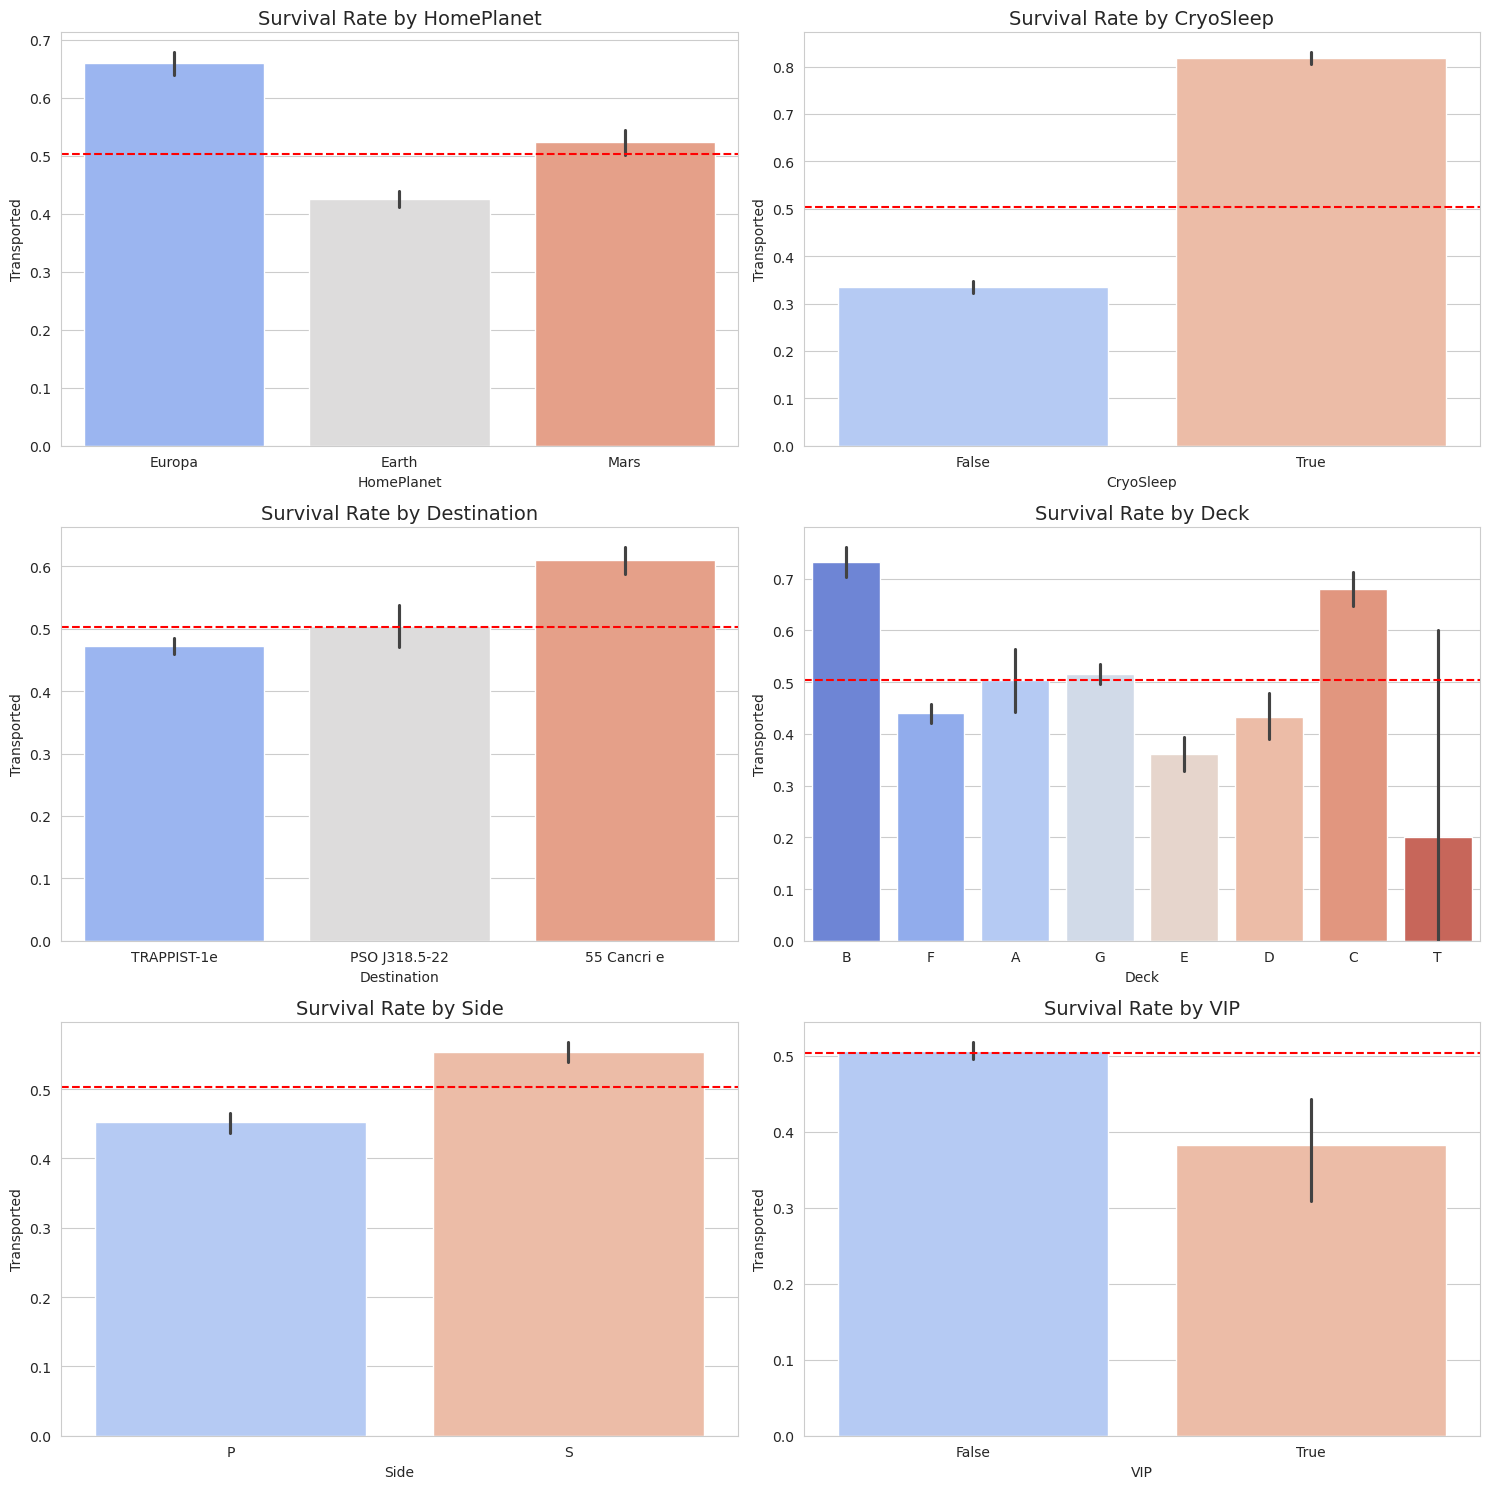

In [35]:
# 문자열(범주형) 변수 목록
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'Deck', 'Side', 'VIP']

plt.figure(figsize=(15, 15))

for i, feature in enumerate(cat_features):
    plt.subplot(3, 2, i+1)
    # 각 범주별 Transported의 평균(생존율)을 계산하여 막대 그래프로 표시
    sns.barplot(data=train_analysis, x=feature, y='Transported', palette='coolwarm')
    plt.title(f'Survival Rate by {feature}', fontsize=14)
    plt.axhline(y=y.mean(), color='r', linestyle='--', label='Average Survival Rate') # 전체 평균선

plt.tight_layout()
plt.show()

결론:  
1. CryoSleep을 한 사람들이 2배 더 많이 살아남았다.
2. 실제로는 Earth 승객들 비율이 2배 정도 높으나, 살아남은 비율은 Europa>Mars>Earth이다.
3. 도착지가 55 cancrie인 사람들이 많이 살아남았다.
4. side 변수는 생존률과 큰 연관성이 없어보인다! featrue 삭제도 나중에 가능할 듯

Group(정수형)과 생존율의 상관관계: 0.0215
GroupSize(일행 수)와 생존율의 상관관계: 0.0826


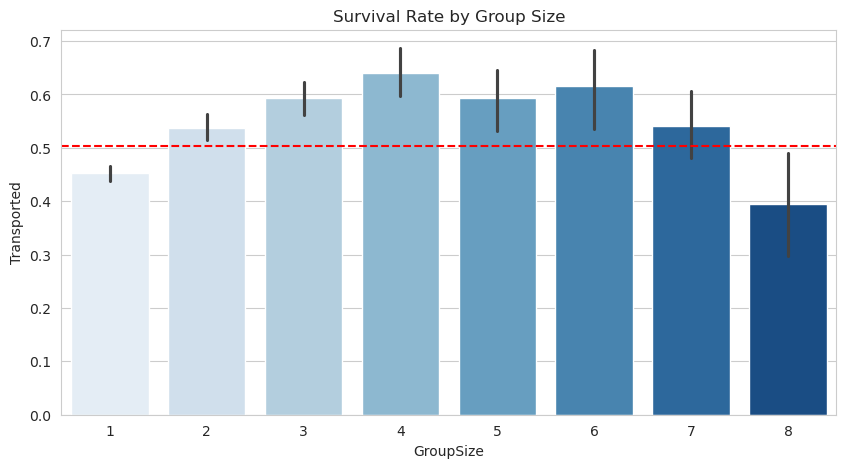

In [36]:
#그룹변수의 의미 파악해보기
#group을 int화 했을 때 y와의 관계 vs GroupSize로 파악해보기
# 1. Group 번호를 정수(int)로 변환
data['Group'] = data['Group'].astype(int)

# 2. 그룹별 인원수(GroupSize) 계산
# 같은 Group 번호를 가진 행이 몇 개인지 세어서 새로운 컬럼을 만듭니다.
data['GroupSize'] = data.groupby('Group')['Group'].transform('count')

# 3. 분석용 데이터 (훈련 데이터 부분만 추출)
train_analysis = data.iloc[:train_len].copy()
train_analysis['Transported'] = y

# 4. 상관계수 확인
group_corr = train_analysis[['Group', 'Transported']].corr().iloc[0, 1]
groupsize_corr = train_analysis[['GroupSize', 'Transported']].corr().iloc[0, 1]

print(f"Group(정수형)과 생존율의 상관관계: {group_corr:.4f}")
print(f"GroupSize(일행 수)와 생존율의 상관관계: {groupsize_corr:.4f}")

# 5. 시각화로 확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=train_analysis, x='GroupSize', y='Transported', palette='Blues')
plt.title('Survival Rate by Group Size')
plt.axhline(y=train_analysis['Transported'].mean(), color='r', linestyle='--')
plt.show()

결론:  
1. ID의 의미인 group의 정수형보다 groupsize가 4배 더 생존율과 관계 있음.
2. group 변수 버리고 groupsize 취하기

In [37]:
#최종 변수 설정
data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Group', 'Deck', 'Num', 'Side', 'TotalSpend', 'GroupSize'],
      dtype='object')

In [38]:
columns = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Deck','Num', 'Side', 'TotalSpend', 'GroupSize']

## 2-4. 범주형 변수들 타겟코딩 또는 원핫코딩

In [39]:
# # 이진 범주형 → Label Encoding
# binary_cols = ['CryoSleep', 'VIP', 'Side']

# # 다중 범주형 → Target Encoding 또는 OHE
# multi_cols = ['HomePlanet', 'Destination', 'Deck']

# # Target Encoding 예시 (leakage 방지 위해 cross_val로)
# from category_encoders import TargetEncoder
# enc = TargetEncoder(cols=multi_cols)
# x_encoded = enc.fit_transform(x, y)

# 3. 모델 selection  
각 변수들과 y가 선형관계를 이루지 않으며,  
범주형 타겟이 많아 Catboost를 사용해본다.

In [40]:
!pip install catboost

## 3-1. CatBoost모델 교차검증

### 1st model

In [41]:
columns = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Deck','Num', 'Side', 'TotalSpend', 'GroupSize']

data1 = data[columns]
test = data1.iloc[train_len:, :]
x = data1.iloc[:train_len, :]

In [42]:
# 교차검증
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_scores = []
oof_f1 = []

all_val_preds = []
all_val_true = []

for fold, (train_idx, val_idx) in enumerate(skf.split(x, y)):
    x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='Accuracy',
        random_seed=42,
        verbose=False,
        early_stopping_rounds=50
    )

    model.fit(
        x_train, y_train,
        cat_features=cat_features,
        eval_set=(x_val, y_val)
    )

    preds = model.predict(x_val)
    oof_scores.append(accuracy_score(y_val, preds))
    oof_f1.append(f1_score(y_val, preds))

    all_val_preds.extend(preds)
    all_val_true.extend(y_val)

    print(f"Fold {fold+1}  Accuracy: {oof_scores[-1]:.4f}  F1: {oof_f1[-1]:.4f}")

print(f"\n Mean Accuracy : {np.mean(oof_scores):.4f} ± {np.std(oof_scores):.4f}")
print(f" Mean F1 Score : {np.mean(oof_f1):.4f} ± {np.std(oof_f1):.4f}")

Fold 1  Accuracy: 0.7614  F1: 0.7477
Fold 2  Accuracy: 0.7642  F1: 0.7545
Fold 3  Accuracy: 0.7642  F1: 0.7518
Fold 4  Accuracy: 0.7664  F1: 0.7506
Fold 5  Accuracy: 0.7612  F1: 0.7446

 Mean Accuracy : 0.7635 ± 0.0020
 Mean F1 Score : 0.7499 ± 0.0034


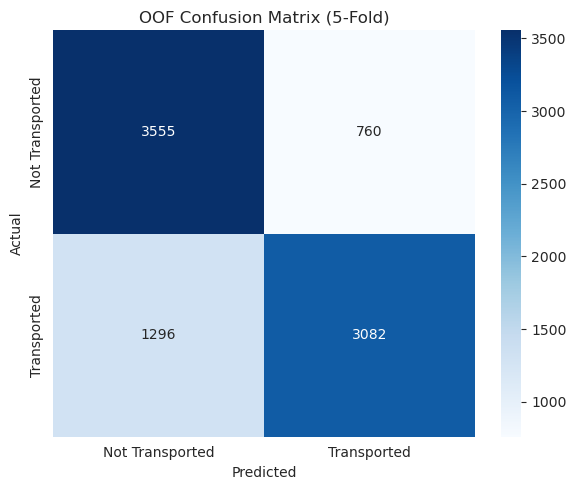

                 precision    recall  f1-score   support

Not Transported       0.73      0.82      0.78      4315
    Transported       0.80      0.70      0.75      4378

       accuracy                           0.76      8693
      macro avg       0.77      0.76      0.76      8693
   weighted avg       0.77      0.76      0.76      8693



In [43]:
# 혼동행렬 및 평가지표
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_val_true, all_val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title('OOF Confusion Matrix (5-Fold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(all_val_true, all_val_preds,
                             target_names=['Not Transported', 'Transported']))

#### Feature Importace

       feature  importance
8   TotalSpend   34.036399
0   HomePlanet   22.063553
1    CryoSleep   11.386531
6          Num    9.201932
5         Deck    8.169162
2  Destination    6.394964
7         Side    5.377449
3          Age    2.518412
9    GroupSize    0.739712
4          VIP    0.111887


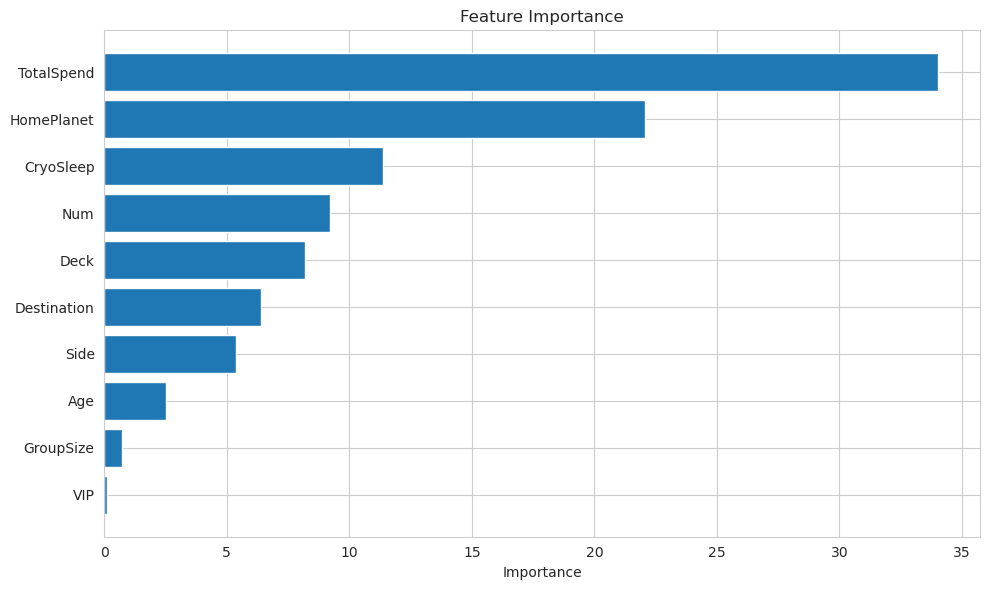

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 마지막 fold의 model 사용 (또는 final_model)
feature_importance = model.get_feature_importance()
feature_names = x.columns.tolist()

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(fi_df)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

결론:
totalspend가 너무 큰 영향력을 발휘함. 이걸 줄여야할 것 같음.
VIP는 의미없는 변수임. 삭제!

### 2nd moddel

In [45]:
columns = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'Deck','Num', 'Side', 'GroupSize', 'Spa', 'VRDeck', 'RoomService', 'FoodCourt', 'ShoppingMall']

data2 = data[columns]
test = data2.iloc[train_len:, :]
x = data2.iloc[:train_len, :]

In [46]:
# 교차검증
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'Deck', 'Side']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_scores = []
oof_f1 = []

all_val_preds = []
all_val_true = []

for fold, (train_idx, val_idx) in enumerate(skf.split(x, y)):
    x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric='Accuracy',
        random_seed=42,
        verbose=False,
        early_stopping_rounds=50
    )

    model.fit(
        x_train, y_train,
        cat_features=cat_features,
        eval_set=(x_val, y_val)
    )

    preds = model.predict(x_val)
    oof_scores.append(accuracy_score(y_val, preds))
    oof_f1.append(f1_score(y_val, preds))

    all_val_preds.extend(preds)
    all_val_true.extend(y_val)

    print(f"Fold {fold+1}  Accuracy: {oof_scores[-1]:.4f}  F1: {oof_f1[-1]:.4f}")

print(f"\n Mean Accuracy : {np.mean(oof_scores):.4f} ± {np.std(oof_scores):.4f}")
print(f" Mean F1 Score : {np.mean(oof_f1):.4f} ± {np.std(oof_f1):.4f}")

Fold 1  Accuracy: 0.8137  F1: 0.8155
Fold 2  Accuracy: 0.8114  F1: 0.8161
Fold 3  Accuracy: 0.8206  F1: 0.8249
Fold 4  Accuracy: 0.8205  F1: 0.8261
Fold 5  Accuracy: 0.7963  F1: 0.7991

 Mean Accuracy : 0.8125 ± 0.0089
 Mean F1 Score : 0.8163 ± 0.0097


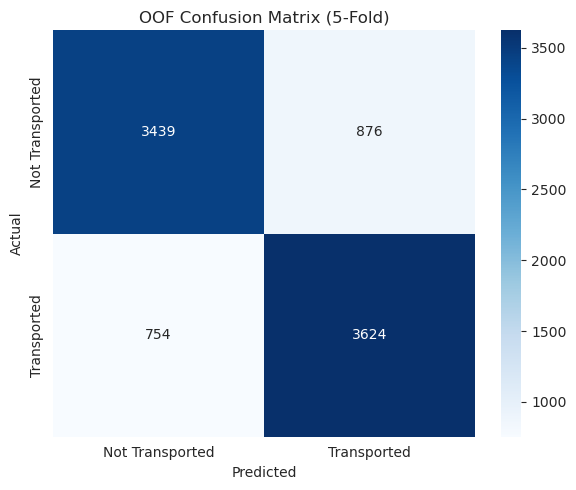

                 precision    recall  f1-score   support

Not Transported       0.82      0.80      0.81      4315
    Transported       0.81      0.83      0.82      4378

       accuracy                           0.81      8693
      macro avg       0.81      0.81      0.81      8693
   weighted avg       0.81      0.81      0.81      8693



In [47]:
# 혼동행렬 및 평가지표
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_val_true, all_val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title('OOF Confusion Matrix (5-Fold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(all_val_true, all_val_preds,
                             target_names=['Not Transported', 'Transported']))

#### Feature Importance

         feature  importance
0     HomePlanet   22.217219
1      CryoSleep   15.450277
8            Spa   12.396561
9         VRDeck   10.805197
10   RoomService    9.145286
5            Num    6.293759
11     FoodCourt    5.843565
4           Deck    5.543557
6           Side    4.272507
3            Age    3.033823
12  ShoppingMall    2.657971
2    Destination    2.149490
7      GroupSize    0.190786


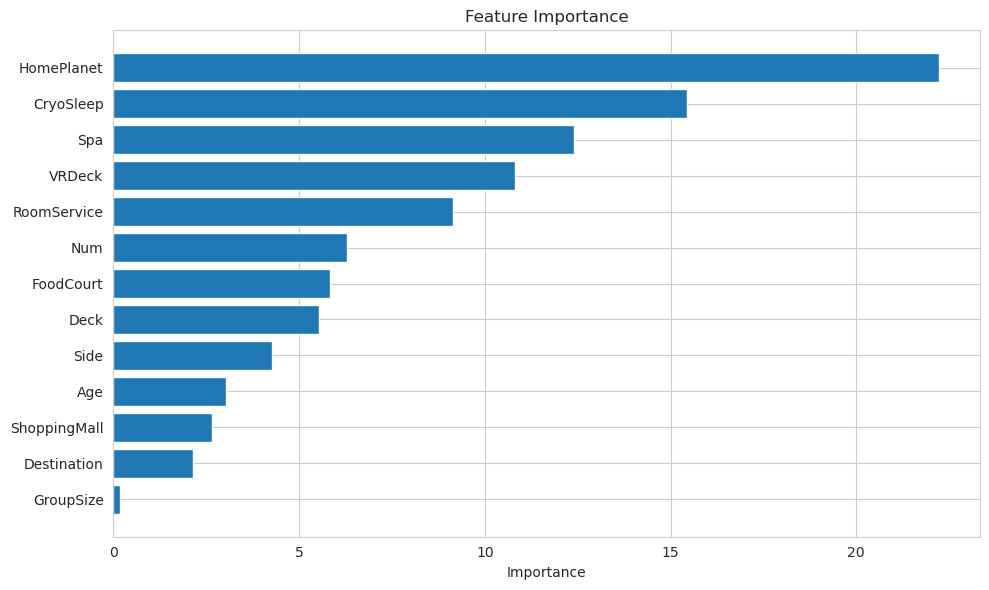

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 마지막 fold의 model 사용 (또는 final_model)
feature_importance = model.get_feature_importance()
feature_names = x.columns.tolist()

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(fi_df)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

결론:  
1. 낮은 피처 제거 테스트


## 최종 모델하이퍼 튜닝

In [49]:
!pip install optuna

In [50]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

columns = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'Deck','Num', 'Side', 'GroupSize', 'Spa', 'VRDeck', 'RoomService', 'FoodCourt', 'ShoppingMall']

data2 = data[columns]
test = data2.iloc[train_len:, :]
x = data2.iloc[:train_len, :]

In [51]:
# cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'Deck', 'Side']

# def objective(trial):
#     params = {
#         'iterations': trial.suggest_int('iterations', 500, 2000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#         'depth': trial.suggest_int('depth', 4, 10),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
#         'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
#         'random_strength': trial.suggest_float('random_strength', 0, 1),
#     }

#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     scores = []

#     for train_idx, val_idx in skf.split(x, y):
#         x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
#         y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#         model = CatBoostClassifier(
#             **params,
#             eval_metric='Accuracy',
#             random_seed=42,
#             verbose=False,
#             early_stopping_rounds=50
#         )
#         model.fit(x_train, y_train,
#                   cat_features=cat_features,
#                   eval_set=(x_val, y_val))

#         scores.append(accuracy_score(y_val, model.predict(x_val)))

#     return np.mean(scores)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print(f"\n✅ Best Accuracy: {study.best_value:.4f}")
# print(f"✅ Best Params: {study.best_params}")

위 튜닝 결과는 이렇게 나옴.  
✅ Best Accuracy: 0.8172  
✅ Best Params: {'iterations': 925, 'learning_rate': 0.08492305861000736, 'depth': 9, 'l2_leaf_reg': 6.097238636964064, 'bagging_temperature': 0.40663301391148804, 'random_strength': 0.8058808963108591}

그러나, Feature importance 결과가 이상해짐.
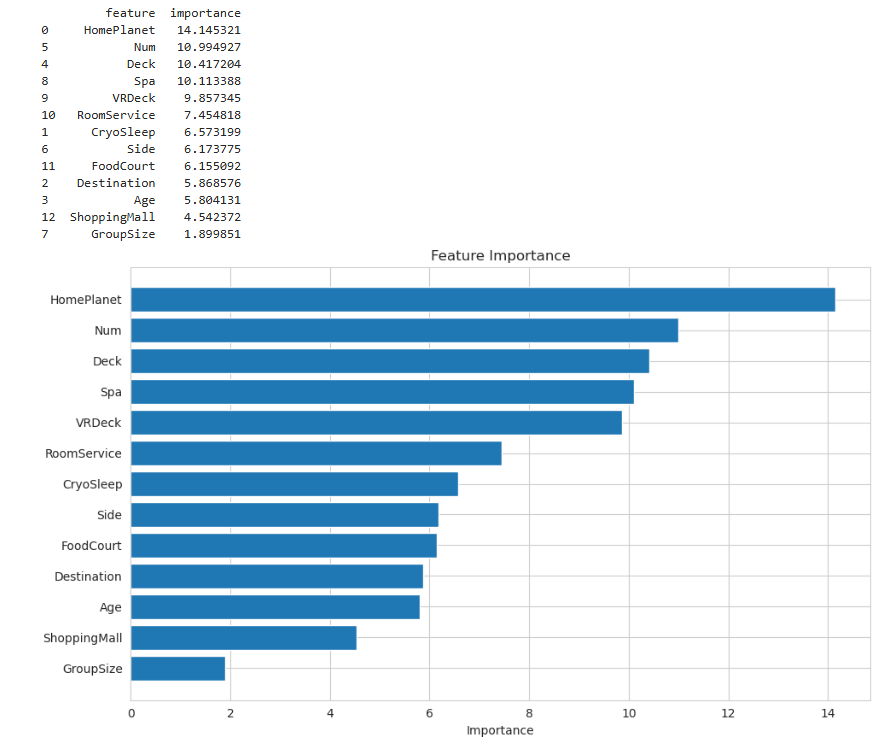

그래서 튜닝 전 모델로 최종 모델 선정.

## 최종 모델

In [52]:
columns = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'Deck','Num', 'Side', 'GroupSize', 'Spa', 'VRDeck', 'RoomService', 'FoodCourt', 'ShoppingMall']
data2 = data[columns]
test = data2.iloc[train_len:, :]
x = data2.iloc[:train_len, :]

cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'Deck', 'Side']

final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50
)

final_model.fit(x, y, cat_features=cat_features)
print(" 학습 완료")

 학습 완료


# 제출

In [53]:
#모델 테스팅
predictions = final_model.predict(test)

In [55]:
# test.csv에서 PassengerId 가져오기
test_original = pd.read_csv(os.path.join(data_dir, 'test.csv'))
submission = pd.DataFrame({
    'PassengerId': test_original['PassengerId'],
    'Transported': predictions.astype(bool)
})

submission.to_csv(os.path.join(data_dir, 'submission.csv'), index=False)
print(submission.head())
print(f"\n✅ submission.csv 저장 완료 ({len(submission)}행)")

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

✅ submission.csv 저장 완료 (4277행)


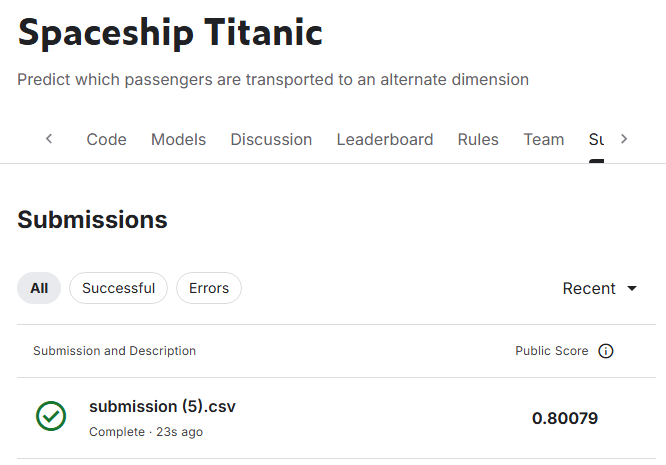

# 회고  
1. 변수를 최소화하면 좋을 줄 알았는데, 초기 TotalSpend 단일 변수보다 개별 지출 항목(Spa, VRDeck, RoomService 등)으로 세분화했을 때 0.76 → 0.80으로 가장 큰 성능 향상을 얻었다.
2. 범주형 변수가 많은 데이터셋에서 CatBoost는 별도 인코딩 없이 바로 사용할 수 있어 전처리 부담이 적고 효과적이었다.
3. 데이터를 좀 더 잘 들여다보는 훈련이 필요할 것 같다. 데이터의 관계성을 파악하는 게 쉽지 않은 것 같다.
4. 튜닝을 한다고 항상 좋아지는 것이 아니다. 